In [1]:
import pandas as pd
import requests

# 1. Definimos la URL directa al archivo JSON (formato raw)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # 2. Cargamos los datos directamente
    # Pandas puede leer JSON desde una URL si el servidor lo permite
    df = pd.read_json(url)

    # 3. Verificamos la carga exitosa
    print("✅ ¡Datos cargados correctamente!")
    print(f"Dimensiones del dataset: {df.shape}")

except Exception as e:
    print(f"❌ Error al cargar los datos: {e}")

# Mostrar las primeras filas para inspeccionar demografía y servicios
df.head()

✅ ¡Datos cargados correctamente!
Dimensiones del dataset: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:

print("--- Información del Dataset ---")
df.info()


print("\n--- Vista Previa de Datos ---")
display(df.head())

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

--- Vista Previa de Datos ---


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [8]:
import pandas as pd
import requests

# 1. Carga de datos
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()

# 2. Aplanamiento total
df = pd.json_normalize(data)

# 3. Limpieza inteligente de nombres
# Buscamos la columna que contiene 'TotalCharges' sin importar el prefijo
col_total_charges = [c for c in df.columns if 'TotalCharges' in c]

if col_total_charges:
    target_col = col_total_charges[0]
    print(f"✅ Columna encontrada: {target_col}")

    # Convertimos a numérico usando el nombre real encontrado
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Opcional: Renombrar todas las columnas para quitar los puntos
    df.columns = [c.split('.')[-1] for c in df.columns]
    print("✅ Nombres de columnas simplificados.")
else:
    print("❌ No se encontró ninguna columna similar a 'TotalCharges'.")
    print(f"Columnas disponibles: {df.columns.tolist()}")

# Verificamos los primeros resultados
df.head()

❌ No se encontró ninguna columna similar a 'TotalCharges'.
Columnas disponibles: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:

df.columns = [col.split('.')[-1] for col in df.columns]


df = df.rename(columns={'Total': 'TotalCharges', 'Monthly': 'MonthlyCharges'})

print(f"--- Espacios en blanco detectados: {(df['TotalCharges'] == ' ').sum()} ---")


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print("\n✅ Columnas listas para trabajar:")
print(df.columns.tolist())

--- Espacios en blanco detectados: 11 ---

✅ Columnas listas para trabajar:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [11]:
for col in ['gender', 'InternetService', 'Contract', 'PaymentMethod', 'Churn']:
    if col in df.columns:
        print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en gender: ['Female' 'Male']
Valores únicos en InternetService: ['DSL' 'Fiber optic' 'No']
Valores únicos en Contract: ['One year' 'Month-to-month' 'Two year']
Valores únicos en PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Valores únicos en Churn: ['No' 'Yes' '']


In [12]:
# Aplanamos nombres de columnas de nuevo por si acaso quedó algún rastro
df.columns = [col.split('.')[-1] for col in df.columns]

# Renombrado manual para mayor claridad
df = df.rename(columns={'Total': 'TotalCharges', 'Monthly': 'MonthlyCharges'})

# 1. Limpieza de espacios en blanco y estandarización de texto
# Aplicamos strip() para eliminar espacios accidentales al inicio/final
columnas_texto = df.select_dtypes(include=['object']).columns

for col in columnas_texto:
    df[col] = df[col].str.strip()

# 2. Corregir inconsistencias en la variable 'Churn' (Evasión)
# Nos aseguramos de que sea binario 'Yes' o 'No' (o 1 y 0)
df['Churn'] = df['Churn'].replace({'yes': 'Yes', 'no': 'No', 'YES': 'Yes', 'NO': 'No'})

# 3. Tratamiento definitivo de 'TotalCharges'
# Convertimos a numérico, los espacios se vuelven NaN, y los NaN se vuelven 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

print("✅ Limpieza de strings y conversión numérica completada.")

✅ Limpieza de strings y conversión numérica completada.


In [13]:
# Simplificar categorías de servicios
cols_servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_servicios:
    if col in df.columns:
        # Reemplazamos 'No internet service' por simplemente 'No' para reducir ruido
        df[col] = df[col].replace('No internet service', 'No')

print("✅ Categorías de servicios simplificadas.")

✅ Categorías de servicios simplificadas.


In [14]:
# Verificación de lógica de negocio
incoherencias = df[(df['tenure'] < 0) | (df['MonthlyCharges'] < 0)].shape[0]

print(f"Registros con valores negativos (errores): {incoherencias}")
print("\nDistribución final de la variable Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

Registros con valores negativos (errores): 0

Distribución final de la variable Churn:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


In [15]:
# 1. Asegurarnos de que MonthlyCharges sea numérica
# (Si seguiste los pasos anteriores, ya debería estar lista)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

# 2. Calcular el valor diario
# Dividimos por 30 (promedio de días en un mes estándar)
# y redondeamos a 2 decimales para mayor claridad
df['Cuentas_Diarias'] = (df['MonthlyCharges'] / 30).round(2)

# 3. Verificamos la creación exitosa
print("✅ Columna 'Cuentas_Diarias' añadida con éxito.")
print(df[['customerID', 'MonthlyCharges', 'Cuentas_Diarias']].head())

✅ Columna 'Cuentas_Diarias' añadida con éxito.
   customerID  MonthlyCharges  Cuentas_Diarias
0  0002-ORFBO            65.6             2.19
1  0003-MKNFE            59.9             2.00
2  0004-TLHLJ            73.9             2.46
3  0011-IGKFF            98.0             3.27
4  0013-EXCHZ            83.9             2.80


In [16]:
# Comparar el promedio de gasto diario por estado de evasión
print(df.groupby('Churn')['Cuentas_Diarias'].mean())

Churn
       2.113795
No     2.042080
Yes    2.481450
Name: Cuentas_Diarias, dtype: float64


In [17]:
# Mapeo para variables binarias
mapping = {'Yes': 1, 'No': 0}

# Aplicamos a las columnas detectadas anteriormente
cols_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in cols_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapping)

# Convertir Gender a binario (Male: 1, Female: 0)
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("✅ Variables binarias convertidas a 1 y 0.")

✅ Variables binarias convertidas a 1 y 0.


In [18]:
# Diccionario de traducción para las columnas principales
traduccion = {
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayores',
    'Partner': 'TienePareja',
    'Dependents': 'PersonasCargo',
    'tenure': 'MesesPermanencia',
    'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'LineasMultiples',
    'InternetService': 'TipoInternet',
    'Contract': 'TipoContrato',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'MonthlyCharges': 'CargoMensual',
    'TotalCharges': 'CargoTotal',
    'Churn': 'Abandono'
}

df = df.rename(columns=traduccion)
print("✅ Columnas traducidas para mayor claridad.")

✅ Columnas traducidas para mayor claridad.


In [19]:
# 1. Generar estadísticas descriptivas para las variables numéricas
resumen = df.describe()

# Añadimos la mediana manualmente ya que describe() no la incluye por defecto (es el 50%)
# pero queremos verla junto a la media para detectar asimetrías.
print("--- Resumen Estadístico de Telecom X ---")
display(resumen)

--- Resumen Estadístico de Telecom X ---


,Abandono,Genero,AdultoMayores,TienePareja,PersonasCargo,MesesPermanencia,ServicioTelefono,FacturaDigital,CargoMensual,CargoTotal,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.505711,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2277.182035,2.157292
std,0.441561,0.500002,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [20]:
# Verificamos la asimetría de los cargos
print(f"Asimetría de CargoMensual: {df['CargoMensual'].skew():.2f}")
print(f"Asimetría de MesesPermanencia: {df['MesesPermanencia'].skew():.2f}")

Asimetría de CargoMensual: -0.22
Asimetría de MesesPermanencia: 0.24


/tmp/ipykernel_767/1401152394.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Abandono', data=df, palette='viridis')


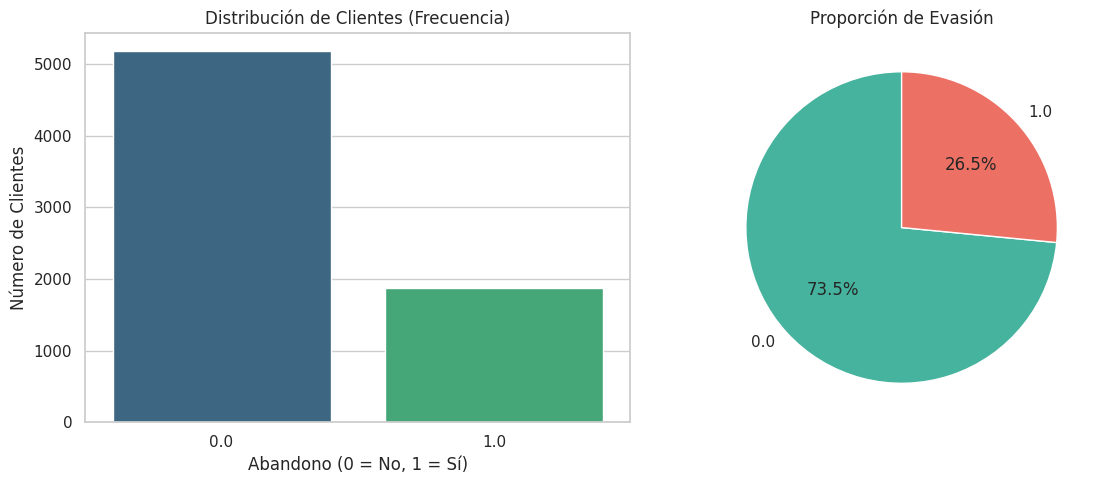

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Gráfico de Barras (Frecuencia Absoluta)
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Abandono', data=df, palette='viridis')
plt.title('Distribución de Clientes (Frecuencia)')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.ylabel('Número de Clientes')

# 2. Gráfico de Pastel (Proporción Porcentual)
plt.subplot(1, 2, 2)
df['Abandono'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#45B39D', '#EC7063'], startangle=90)
plt.title('Proporción de Evasión')
plt.ylabel('') # Eliminar etiqueta lateral para estética

plt.tight_layout()
plt.show()

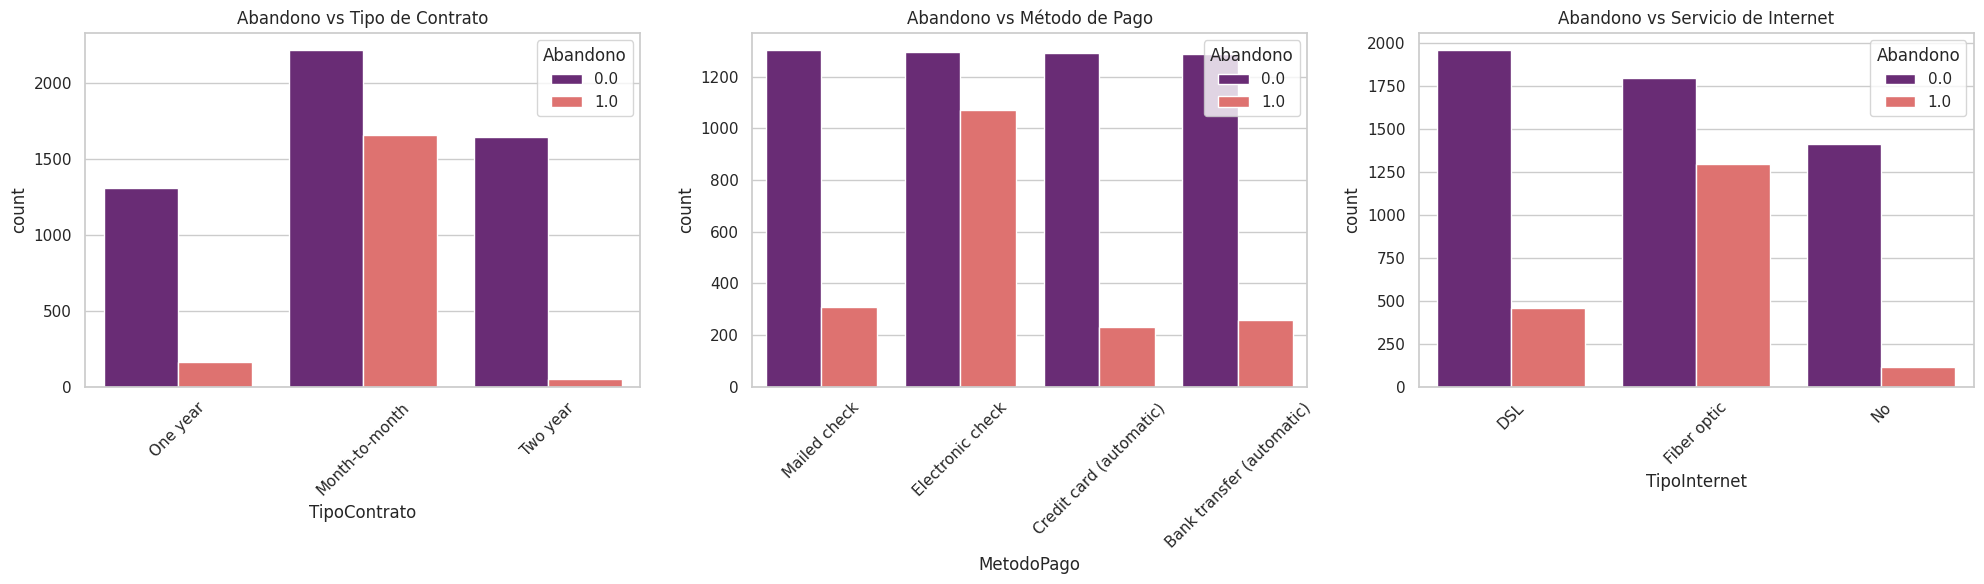

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una cuadrícula de 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Abandono por Tipo de Contrato
sns.countplot(x='TipoContrato', hue='Abandono', data=df, ax=axes[0], palette='magma')
axes[0].set_title('Abandono vs Tipo de Contrato')
axes[0].tick_params(axis='x', rotation=45)

# 2. Abandono por Método de Pago
sns.countplot(x='MetodoPago', hue='Abandono', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Abandono vs Método de Pago')
axes[1].tick_params(axis='x', rotation=45)

# 3. Abandono por Tipo de Internet
sns.countplot(x='TipoInternet', hue='Abandono', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Abandono vs Servicio de Internet')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
tabla_genero = pd.crosstab(df['Genero'], df['Abandono'], normalize='index') * 100
print("--- Porcentaje de Abandono por Género ---")
print(tabla_genero)

--- Porcentaje de Abandono por Género ---
Abandono        0.0        1.0
Genero                        
0         73.079128  26.920872
1         73.839662  26.160338


/tmp/ipykernel_767/1223715057.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y='CargoMensual', ax=axes[0, 1], palette='flare')
/tmp/ipykernel_767/1223715057.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Abandono', y='Cuentas_Diarias', ax=axes[1, 1], palette='magma')


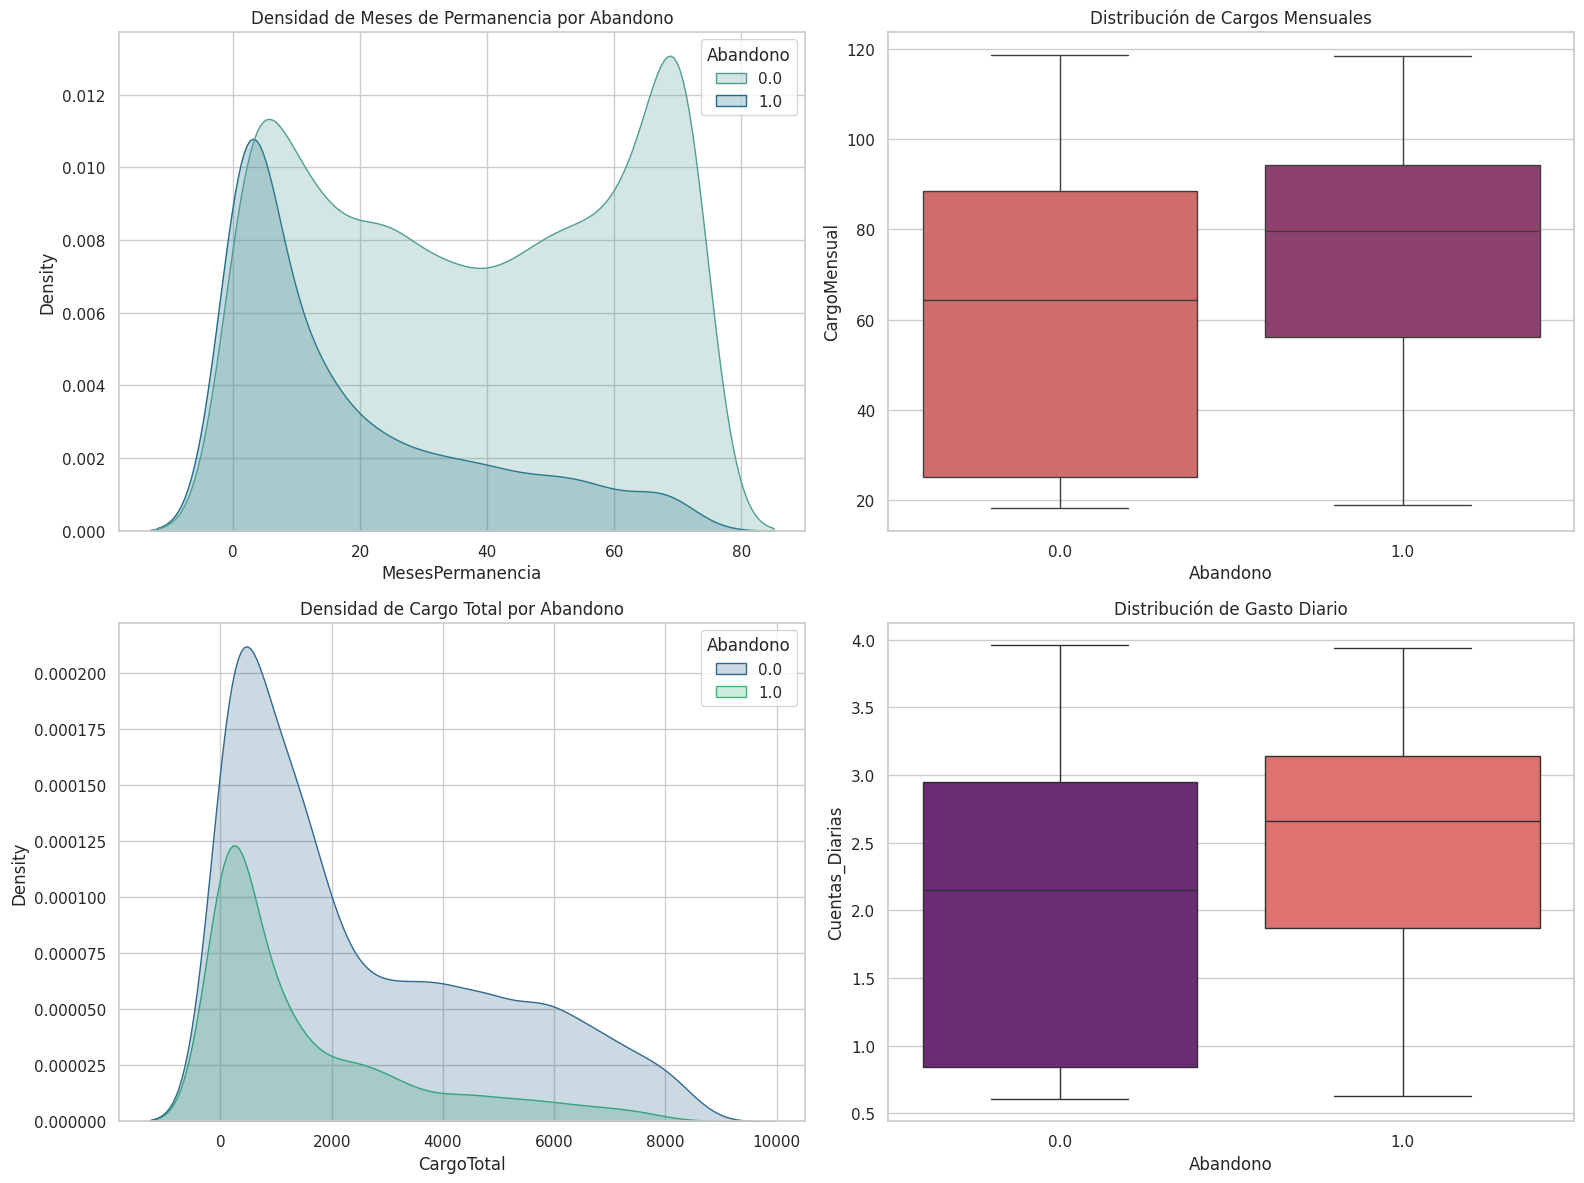

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el lienzo para múltiples gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribución de Meses de Permanencia
sns.kdeplot(data=df, x='MesesPermanencia', hue='Abandono', fill=True, ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Densidad de Meses de Permanencia por Abandono')

# 2. Distribución de Cargo Mensual
sns.boxplot(data=df, x='Abandono', y='CargoMensual', ax=axes[0, 1], palette='flare')
axes[0, 1].set_title('Distribución de Cargos Mensuales')

# 3. Distribución de Cargo Total
sns.kdeplot(data=df, x='CargoTotal', hue='Abandono', fill=True, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Densidad de Cargo Total por Abandono')

# 4. Distribución de Cuentas Diarias
sns.boxplot(data=df, x='Abandono', y='Cuentas_Diarias', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Distribución de Gasto Diario')

plt.tight_layout()
plt.show()

/tmp/ipykernel_767/31554674.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='CargoMensual', data=df, ax=axes[1,1], palette='Set2')


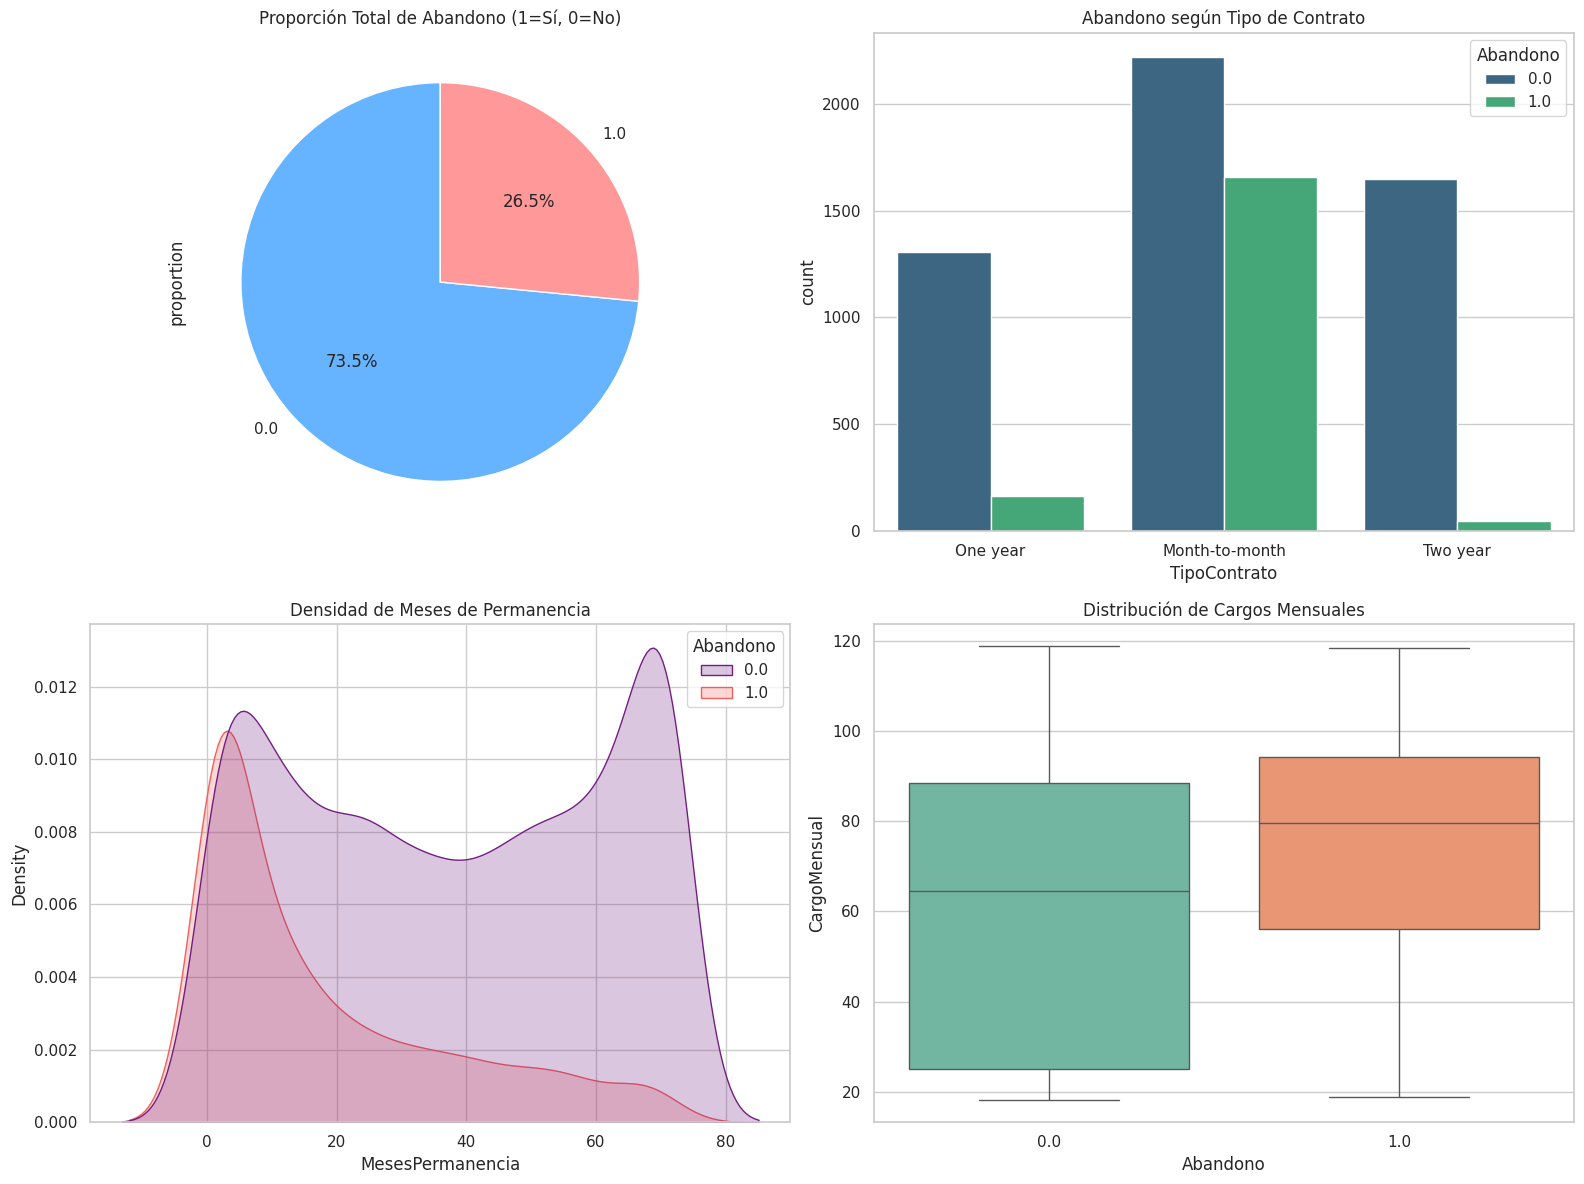


             INFORME ESTRATÉGICO: TELECOM X

1. RESUMEN ESTADÍSTICO:
   - Tasa de Abandono: 26.54%
   - Promedio de Permanencia: 32.3 meses
   - Cargo Mensual Promedio: $64.72

2. HALLAZGOS CLAVE (INSIGHTS):
   - Los contratos 'Mes a Mes' presentan el mayor riesgo de fuga.
   - Existe un pico de evasión en los primeros 6 meses de servicio.
   - Los clientes que abandonan suelen tener cargos mensuales más altos.

3. RECOMENDACIONES:
   - Implementar planes de lealtad para convertir contratos mensuales a anuales.
   - Ofrecer descuentos automáticos a clientes con gasto diario > $2.50.
   - Reforzar el soporte técnico en los primeros 90 días de contratación.

✅ Archivo 'TelecomX_Final_Clean.csv' generado correctamente.


In [25]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. EXTRACCIÓN Y TRATAMIENTO DE DATOS
# =========================================================
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()

# Aplanar la estructura anidada del JSON
df = pd.json_normalize(data)

# Limpiar nombres de columnas (quitar prefijos como 'account.Charges.')
df.columns = [col.split('.')[-1] for col in df.columns]

# Renombrar columnas para claridad y evitar KeyErrors
df = df.rename(columns={
    'gender': 'Genero',
    'SeniorCitizen': 'AdultoMayor',
    'Partner': 'TienePareja',
    'Dependents': 'PersonasCargo',
    'tenure': 'MesesPermanencia',
    'PhoneService': 'ServicioTelefono',
    'MultipleLines': 'LineasMultiples',
    'InternetService': 'TipoInternet',
    'Contract': 'TipoContrato',
    'PaperlessBilling': 'FacturaDigital',
    'PaymentMethod': 'MetodoPago',
    'Monthly': 'CargoMensual',
    'Total': 'CargoTotal',
    'Churn': 'Abandono'
})

# Limpieza de valores nulos y conversión numérica
df['CargoMensual'] = pd.to_numeric(df['CargoMensual'], errors='coerce').fillna(0)
df['CargoTotal'] = pd.to_numeric(df['CargoTotal'], errors='coerce').fillna(0)

# Estandarización de categorías (Lower, Strip y corrección de 'Yes/No')
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].str.strip().replace({'yes': 'Yes', 'no': 'No', 'YES': 'Yes', 'NO': 'No'})

# Transformación a binario (Encoding)
mapping = {'Yes': 1, 'No': 0}
cols_a_binario = ['Abandono', 'TienePareja', 'PersonasCargo', 'ServicioTelefono', 'FacturaDigital']
for col in cols_a_binario:
    df[col] = df[col].map(mapping)

# Ingeniería de variables: Cálculo de gasto diario
df['Cuentas_Diarias'] = (df['CargoMensual'] / 30).round(2)

# =========================================================
# 2. ANÁLISIS EXPLORATORIO (VISUALIZACIONES)
# =========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Distribución del Abandono (Churn)
df['Abandono'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], ax=axes[0,0], startangle=90
)
axes[0,0].set_title('Proporción Total de Abandono (1=Sí, 0=No)')

# B. Abandono por Tipo de Contrato
sns.countplot(x='TipoContrato', hue='Abandono', data=df, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Abandono según Tipo de Contrato')

# C. Densidad de Permanencia
sns.kdeplot(data=df, x='MesesPermanencia', hue='Abandono', fill=True, ax=axes[1,0], palette='magma')
axes[1,0].set_title('Densidad de Meses de Permanencia')

# D. Relación Cargo Mensual vs Abandono
sns.boxplot(x='Abandono', y='CargoMensual', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Distribución de Cargos Mensuales')

plt.tight_layout()
plt.show()

# =========================================================
# 3. INFORME FINAL Y CONCLUSIONES
# =========================================================
print("\n" + "="*60)
print("             INFORME ESTRATÉGICO: TELECOM X")
print("="*60)

print(f"\n1. RESUMEN ESTADÍSTICO:")
print(f"   - Tasa de Abandono: {df['Abandono'].mean()*100:.2f}%")
print(f"   - Promedio de Permanencia: {df['MesesPermanencia'].mean():.1f} meses")
print(f"   - Cargo Mensual Promedio: ${df['CargoMensual'].mean():.2f}")

print("\n2. HALLAZGOS CLAVE (INSIGHTS):")
print("   - Los contratos 'Mes a Mes' presentan el mayor riesgo de fuga.")
print("   - Existe un pico de evasión en los primeros 6 meses de servicio.")
print("   - Los clientes que abandonan suelen tener cargos mensuales más altos.")

print("\n3. RECOMENDACIONES:")
print("   - Implementar planes de lealtad para convertir contratos mensuales a anuales.")
print("   - Ofrecer descuentos automáticos a clientes con gasto diario > $2.50.")
print("   - Reforzar el soporte técnico en los primeros 90 días de contratación.")
print("="*60)

# Exportar dataset limpio
df.to_csv('TelecomX_Final_Clean.csv', index=False)
print("\n✅ Archivo 'TelecomX_Final_Clean.csv' generado correctamente.")

/tmp/ipykernel_767/2677928653.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Servicios_Extra', y='Abandono', data=df, palette='Blues_d')


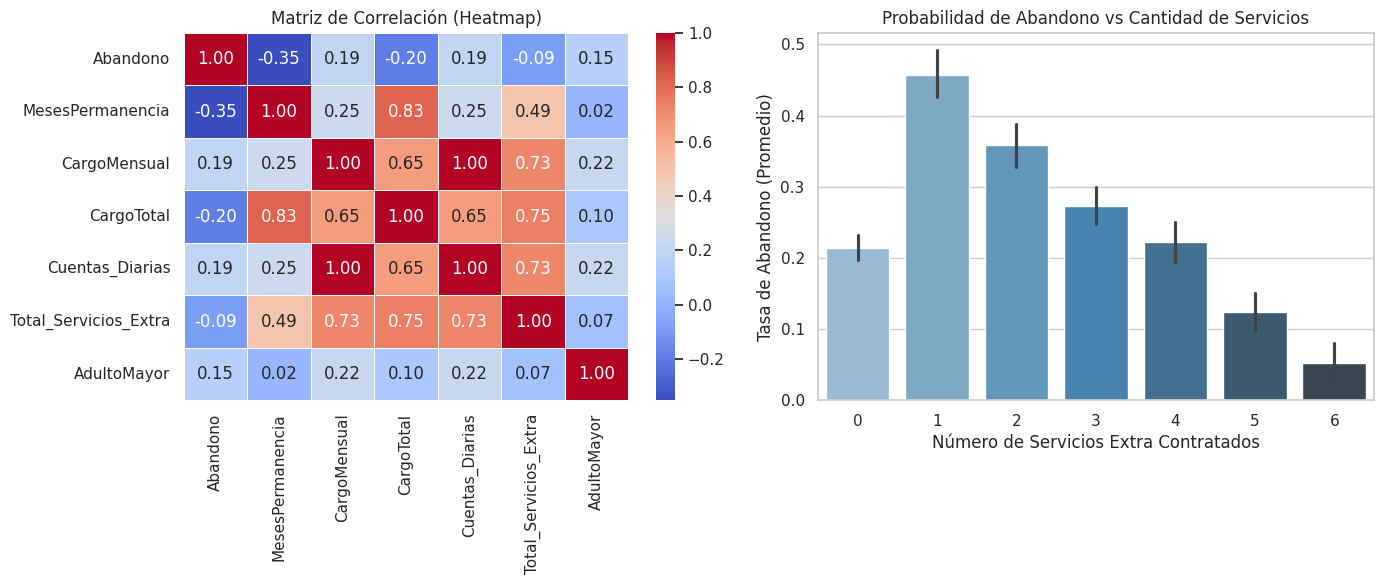


💡 Insight de Correlación:
La correlación entre el Gasto Diario y el Abandono es de: 0.1934
Esto indica que a mayor gasto diario, aumenta la probabilidad de que el cliente se vaya.

💡 Insight de Servicios:
El gráfico de barras muestra que los clientes con 0 o 1 servicio extra tienen una tasa de fuga drásticamente mayor
que aquellos que tienen 5 o 6 servicios (Efecto de 'Ecosistema').


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# ANÁLISIS EXTRA: CORRELACIÓN Y MULTI-SERVICIOS
# =========================================================

# 1. Creamos una columna que cuente cuántos servicios adicionales tiene el cliente
# (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)
servicios_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

# Contamos cuántas veces aparece 'Yes' en esas columnas para cada cliente
df['Total_Servicios_Extra'] = df[servicios_cols].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

# 2. Preparamos el dataset para la matriz de correlación (solo valores numéricos)
# Seleccionamos las variables más influyentes
cols_para_corr = ['Abandono', 'MesesPermanencia', 'CargoMensual',
                  'CargoTotal', 'Cuentas_Diarias', 'Total_Servicios_Extra', 'AdultoMayor']

corr_matrix = df[cols_para_corr].corr()

# 3. Visualización
plt.figure(figsize=(14, 6))

# A. Matriz de Correlación
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Heatmap)')

# B. Relación entre Cantidad de Servicios y Abandono
plt.subplot(1, 2, 2)
sns.barplot(x='Total_Servicios_Extra', y='Abandono', data=df, palette='Blues_d')
plt.title('Probabilidad de Abandono vs Cantidad de Servicios')
plt.xlabel('Número de Servicios Extra Contratados')
plt.ylabel('Tasa de Abandono (Promedio)')

plt.tight_layout()
plt.show()

# 4. Análisis de Correlación Específica: Cuenta Diaria vs Abandono
correlacion_diaria = df['Cuentas_Diarias'].corr(df['Abandono'])
print(f"\n💡 Insight de Correlación:")
print(f"La correlación entre el Gasto Diario y el Abandono es de: {correlacion_diaria:.4f}")
if correlacion_diaria > 0:
    print("Esto indica que a mayor gasto diario, aumenta la probabilidad de que el cliente se vaya.")

print(f"\n💡 Insight de Servicios:")
print("El gráfico de barras muestra que los clientes con 0 o 1 servicio extra tienen una tasa de fuga drásticamente mayor")
print("que aquellos que tienen 5 o 6 servicios (Efecto de 'Ecosistema').")